# Non-Attentive Tacotron (NAT) — Training Notebook

Based on **"Non-Attentive Tacotron: Robust and Controllable Neural TTS Synthesis Including Unsupervised Duration Modeling"** (Shen et al., 2021) arXiv:2010.04301

Key improvement over standard Tacotron2:
- Replaces fragile location-sensitive attention with an explicit **Duration Predictor + Gaussian Upsampling**
- Robustness: 0.005% word deletion vs 16.96% for Tacotron2 (paper Table 2)
- Trains on the **Omani Arabic TTS dataset** (`dataset_new_omani`)

## 0. Install Dependencies

In [1]:
# Run once if needed
! pip install torch torchaudio librosa matplotlib gdown openpyxl soundfile

## 1. Environment Setup

In [1]:
import os, sys
from pathlib import Path

# Locate project root (the folder that contains commons/dataset.py)
ROOT = Path.cwd().resolve()
if ROOT.name in ("tacotron2", "very-attentive-tacotron", "non-attentive-tacotron"):
    ROOT = ROOT.parent
for _ in range(4):
    if (ROOT / "commons" / "dataset.py").exists():
        break
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)

Project root: /content


## 2. Download Omani Dataset

Downloads the `dataset_new_omani` corpus from Google Drive.  
Skipped automatically if the files are already present.

Expected layout after extraction:
```
dataset_new_omani/
├── transcriptions.xlsx
└── clean_flac/
    └── *.flac
```

In [2]:
import subprocess, sys, zipfile, shutil
from pathlib import Path

# ── Google Drive file ID (same zip as omani_speaker_finetune.ipynb) ───────────
DATASET_ZIP_FILE_ID = "1nFMp2NmH4hkuz9Qc7NRjq6OSj7vMAGzQ"

DATASET_DEST = ROOT / "dataset_new_omani"
AUDIO_DIR    = DATASET_DEST / "clean_flac"
XLSX_DEST    = DATASET_DEST / "transcriptions.xlsx"

PATH_NAT_TACO = ROOT / "model"
MODEL_PATH_NAT_TACO = PATH_NAT_TACO / "nat_omani_last.pth"
MODEL_ID = "1ngC1idGpOsTCJqnUhuo9WqWUYqWTH9a9"
# ── Ensure gdown is available ─────────────────────────────────────────────────
try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--root-user-action=ignore", "gdown"])
    import gdown

if not MODEL_PATH_NAT_TACO.exists():
    MODEL_PATH_NAT_TACO.mkdir(parents=True, exist_ok=True)
    gdown.download(id=MODEL_ID, output=str(MODEL_PATH_NAT_TACO), quiet=False, fuzzy=True)
# ── Skip if already present ───────────────────────────────────────────────────
if AUDIO_DIR.exists() and any(AUDIO_DIR.glob("*.flac")) and XLSX_DEST.exists():
    n_flac = len(list(AUDIO_DIR.glob("*.flac")))
    print(f"Dataset already present ({n_flac} flac files) — skipping download.")
else:
    zip_path = DATASET_DEST / "dataset.zip"
    DATASET_DEST.mkdir(parents=True, exist_ok=True)
    AUDIO_DIR.mkdir(exist_ok=True)
    print("Downloading dataset zip from Google Drive ...")
    gdown.download(id=DATASET_ZIP_FILE_ID, output=str(zip_path), quiet=False, fuzzy=True)
    gdown.download(id=MODEL_ID, output=str(MODEL_PATH_NAT_TACO), quiet=False, fuzzy=True)  # Sometimes fails on first try
    print(f"Extracting {zip_path.name} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.namelist():
            filename = Path(member).name
            if not filename:
                continue
            if member.lower().endswith(".flac"):
                with zf.open(member) as src, open(AUDIO_DIR / filename, "wb") as dst:
                    shutil.copyfileobj(src, dst)
            elif member.lower().endswith(".xlsx"):
                with zf.open(member) as src, open(XLSX_DEST, "wb") as dst:
                    shutil.copyfileobj(src, dst)
    zip_path.unlink()
    print(f"Extracted {len(list(AUDIO_DIR.glob('*.flac')))} .flac files → {AUDIO_DIR}")
    print(f"Extracted transcriptions.xlsx → {XLSX_DEST}")

DATASET_ROOT = str(DATASET_DEST)
print("\nDataset root:", DATASET_ROOT)

Dataset already present (4481 flac files) — skipping download.

Dataset root: /content/dataset_new_omani


## 3. Load Dataset

Uses `NewOmaniTTSDataset` from `commons/dataset.py`.  
`TTSCollator` returns a 6-tuple:
```
(text_padded, input_lengths, mel_padded, gate_padded, enc_mask, dec_mask)
```
where `mel_padded` is `(B, T_mel, 80)` and masks use `True = padding`.

[NewOmaniTTSDataset] Filtered 0 samples > 10.0s. Kept 4478.
Total samples : 4478
Speakers      : ['111', '45', '47', '49', '51', '53', '55']
Train: 4031   Val: 447

Batch shapes:
  text_pad  : torch.Size([8, 35])   (B, T_text)
  in_lens   : [35, 32, 30, 29, 27, 26, 20, 14]
  mel_pad   : torch.Size([8, 260, 80])   (B, T_mel, 80)
  gate_pad  : torch.Size([8, 260])  (B, T_mel)
  enc_mask  : torch.Size([8, 35])  (B, T_text) True=pad
  dec_mask  : torch.Size([8, 260])  (B, T_mel)  True=pad


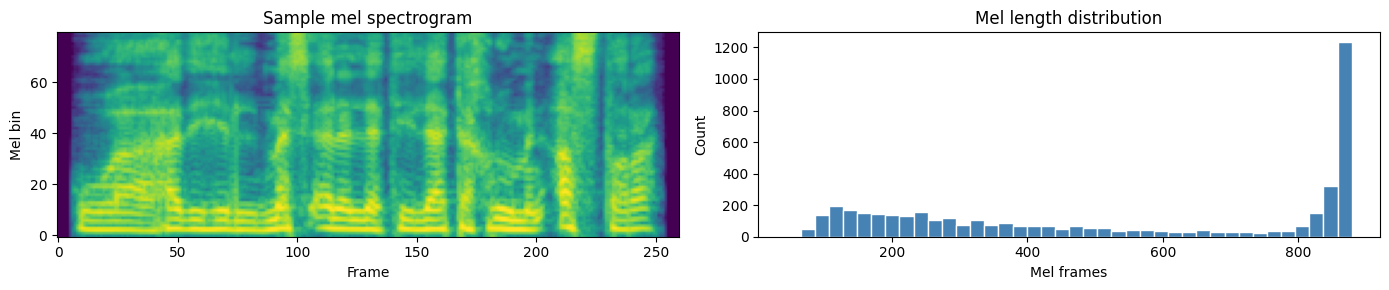


Vocab size: 113


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

from commons.dataset     import NewOmaniTTSDataset, TTSCollator, BucketBatchSampler
from commons.hyperparams import Tacotron2Config
from tacotron2.tokenizer import Tokenizer

config = Tacotron2Config()
tok    = Tokenizer()

BATCH_SIZE     = 8
VAL_SPLIT      = 0.1
VAL_SPLIT_SEED = 42

full_ds = NewOmaniTTSDataset(
    dataset_root      = DATASET_ROOT,
    speakers          = None,
    sample_rate       = config.sample_rate,
    n_fft             = config.n_fft,
    window_size       = config.win_length,
    hop_size          = config.hop_length,
    fmin              = config.fmin,
    fmax              = config.fmax,
    num_mels          = config.n_mels,
    min_db            = config.min_db,
    max_scaled_abs    = config.max_scaled_abs,
    max_audio_seconds = 10.0,
)

print(f"Total samples : {len(full_ds)}")
print(f"Speakers      : {full_ds.available_speakers}")

n_val   = max(1, int(len(full_ds) * VAL_SPLIT))
n_train = len(full_ds) - n_val
gen     = torch.Generator().manual_seed(VAL_SPLIT_SEED)
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=gen)
print(f"Train: {n_train}   Val: {n_val}")

train_mel_lengths = [full_ds.mel_lengths[i] for i in train_ds.indices]
train_sampler     = BucketBatchSampler(
    train_mel_lengths, batch_size=BATCH_SIZE, drop_last=True
)
collate_fn = TTSCollator()
train_dl   = DataLoader(train_ds, batch_sampler=train_sampler,
                        collate_fn=collate_fn, num_workers=0)
val_dl     = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

# Inspect one batch
text_pad, in_lens, mel_pad, gate_pad, enc_mask, dec_mask = next(iter(train_dl))
print(f"\nBatch shapes:")
print(f"  text_pad  : {text_pad.shape}   (B, T_text)")
print(f"  in_lens   : {in_lens.tolist()}")
print(f"  mel_pad   : {mel_pad.shape}   (B, T_mel, 80)")
print(f"  gate_pad  : {gate_pad.shape}  (B, T_mel)")
print(f"  enc_mask  : {enc_mask.shape}  (B, T_text) True=pad")
print(f"  dec_mask  : {dec_mask.shape}  (B, T_mel)  True=pad")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(mel_pad[0].T.cpu().numpy(), aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Sample mel spectrogram")
axes[0].set_xlabel("Frame"); axes[0].set_ylabel("Mel bin")
mel_lens = [full_ds.mel_lengths[i] for i in range(len(full_ds))]
axes[1].hist(mel_lens, bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Mel frames"); axes[1].set_ylabel("Count")
axes[1].set_title("Mel length distribution")
plt.tight_layout(); plt.show()
print(f"\nVocab size: {tok.vocab_size}")

## 4. Ground-Truth Duration Extraction

NAT needs per-token frame counts during training. Two strategies are provided:

1. **Uniform heuristic** (default, no pretrained model needed): distributes mel frames evenly across text tokens. Exact — sum always equals `mel_length`.
2. **Tacotron2 attention-based** (optional): extracts argmax alignment from a pretrained Tacotron2 checkpoint for more accurate per-token durations.

Set `USE_TACOTRON2_DURATIONS = True` and point `TACOTRON2_CHECKPOINT` to a pretrained `.pth` file to use strategy 2.

In [4]:
def compute_uniform_durations(
    input_lengths: torch.Tensor,    # (B,)  real text token counts
    output_lengths: torch.Tensor,   # (B,)  real mel frame counts
) -> torch.Tensor:                  # LongTensor(B, T_text_max)
    """
    Distribute mel frames uniformly across text tokens.
    Remainder frames are added to the last tokens.
    Guarantees: durations[b].sum() == output_lengths[b] for all b.
    """
    B     = input_lengths.shape[0]
    T_max = int(input_lengths.max().item())
    durs  = torch.zeros(B, T_max, dtype=torch.long)
    for b in range(B):
        T_txt = int(input_lengths[b].item())
        T_mel = int(output_lengths[b].item())
        base      = T_mel // T_txt
        remainder = T_mel %  T_txt
        durs[b, :T_txt] = base
        if remainder > 0:
            durs[b, T_txt - remainder : T_txt] += 1
    return durs


def compute_tacotron2_durations(
    taco2_model,
    text_pad, input_lengths, mel_pad, enc_mask, dec_mask,
    device,
) -> torch.Tensor:
    """
    Extract durations from a pretrained Tacotron2 attention matrix.
    Runs Tacotron2 forward (teacher-forced), takes argmax over text dim
    per mel frame, and counts frames per token.
    """
    taco2_model.eval()
    with torch.no_grad():
        _, _, _, attn = taco2_model(
            text_pad.to(device), input_lengths,
            mel_pad.to(device), enc_mask.to(device), dec_mask.to(device)
        )
    # attn: (B, T_mel, T_text)
    B, T_mel, T_text = attn.shape
    attended = attn.argmax(dim=-1)                  # (B, T_mel)  which token each frame attends

    durs = torch.zeros(B, T_text, dtype=torch.long)
    for b in range(B):
        mel_len  = (~dec_mask[b]).sum().item()
        text_len = int(input_lengths[b].item())
        for t in range(mel_len):
            idx = int(attended[b, t].item())
            if idx < text_len:
                durs[b, idx] += 1
        # Ensure each real token gets at least 1 frame
        zero_tok = (durs[b, :text_len] == 0)
        if zero_tok.any():
            max_tok = durs[b, :text_len].argmax().item()
            n_zeros = int(zero_tok.sum().item())
            if durs[b, max_tok] > n_zeros:
                durs[b, max_tok] -= n_zeros
                durs[b, :text_len][zero_tok] = 1
    return durs


# ── Select strategy ─────────────────────────────────────────────────────────
USE_TACOTRON2_DURATIONS = False
TACOTRON2_CHECKPOINT    = str(ROOT / "checkpoints_taco2" / "tacotron2_last.pth")

if USE_TACOTRON2_DURATIONS:
    from tacotron2.model import Tacotron2
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    taco2_model = Tacotron2(config).to(device)
    ck = torch.load(TACOTRON2_CHECKPOINT, map_location=device, weights_only=False)
    taco2_model.load_state_dict(ck["model_state_dict"])
    taco2_model.eval()
    print(f"Loaded Tacotron2 from {TACOTRON2_CHECKPOINT}")
    DURATION_FN = "tacotron2"
else:
    print("Using uniform duration heuristic.")
    DURATION_FN = "uniform"

# Quick sanity check on uniform durations
output_lengths = (~dec_mask.bool()).sum(dim=1)
test_durs      = compute_uniform_durations(in_lens, output_lengths)
assert (test_durs.sum(dim=1) == output_lengths).all(), "Duration sum mismatch!"
print(f"Uniform durations OK — shape {test_durs.shape}, sum matches mel_lengths.")

Using uniform duration heuristic.
Uniform durations OK — shape torch.Size([8, 35]), sum matches mel_lengths.


## 5. Build Model

In [6]:
! ls 

commons  dataset_new_omani  non-attentive-tacotron  sample_data  tacotron2


In [7]:
! ls tacotron2/

combine_clartts_parquets.py   __pycache__
inference.ipynb		      README.md
__init__.py		      tacotron2_training.ipynb
model.py		      tokenizer.py
omani_speaker_finetune.ipynb  train_taco.py
prep_splits.py		      train_taco.sh


In [ ]:
import sys, torch, math
from pathlib import Path

sys.path.insert(0, str(ROOT / 'non-attentive-tacotron'))

from model import NonAttentiveTacotron, NATConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

nat_config = NATConfig(
    vocab_size          = tok.vocab_size,
    n_mels              = config.n_mels,
    character_embed_dim = 512,
    encoder_embed_dim   = 512,
    dur_lstm_units      = 512,
    range_lstm_units    = 512,
    decoder_prenet_dim  = 256,
    decoder_embed_dim   = 1024,
    postnet_n_filters   = 512,
    dur_loss_weight     = 2.0,
)

CKPT_DIR        = ROOT / "checkpoints_nat_omani"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
FINETUNE_EPOCHS = 300
LR              = 1e-3
WARMUP_STEPS    = 4000
SAVE_EVERY      = 30
LOG_EVERY       = 20
GRAD_CLIP       = 1.0

nat_model = NonAttentiveTacotron(nat_config).to(device)
n_params  = sum(p.numel() for p in nat_model.parameters() if p.requires_grad)
print(f"Parameters : {n_params:,}")
print(f"Vocab size : {nat_config.vocab_size}")
print(f"n_mels     : {nat_config.n_mels}")

optimizer = torch.optim.Adam(
    nat_model.parameters(), lr=LR, betas=(0.9, 0.999), eps=1e-6,
    weight_decay=1e-6,
)

total_steps = FINETUNE_EPOCHS * len(train_dl)
def lr_lambda(step):
    step = max(step, 1)
    if step < WARMUP_STEPS:
        return step / WARMUP_STEPS
    decay = 0.5 ** ((step - WARMUP_STEPS) / 50_000)
    return max(0.05, decay)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"Total steps: {total_steps:,}  (epochs={FINETUNE_EPOCHS}, batches/epoch={len(train_dl)})")

# ── Resume from checkpoint ───────────────────────────────────────────────────
def _find_latest_checkpoint(ckpt_dir: Path):
    """Return the most recent checkpoint path, preferring nat_omani_last.pth,
    then the highest-numbered epoch file."""
    last = ckpt_dir / "nat_omani_last.pth"
    if last.exists():
        return last
    epoch_files = sorted(ckpt_dir.glob("nat_omani_epoch_*.pth"))
    return epoch_files[-1] if epoch_files else None

resume_ckpt = _find_latest_checkpoint(CKPT_DIR)
start_epoch = 1

if resume_ckpt is not None:
    print(f"Resuming from checkpoint: {resume_ckpt.name}")
    ck = torch.load(resume_ckpt, map_location=device, weights_only=False)
    nat_model.load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    start_epoch = ck["epoch"] + 1
    # Restore LR schedule to the correct step position
    completed_steps = ck["epoch"] * len(train_dl)
    for _ in range(completed_steps):
        scheduler.step()
    print(f"Restored to epoch {ck['epoch']} — resuming from epoch {start_epoch}")
else:
    print("No checkpoint found — starting from scratch.")


## 6. Loss Function

Exact paper formulation (Eq. 2):
```
L_spec = (1/T·K) · Σ_t [ |y't − y*t|₁ + |y't − y*t|₂² + |yt − y*t|₁ + |yt − y*t|₂² ]
L_dur  = (1/N) · ‖d − d*‖₂²
L_total = L_spec + λ_dur · L_dur
```
- L1 + MSE on both pre-postnet and post-postnet mel outputs
- Duration L2 in raw frame counts (not log), `λ_dur = 2.0`
- All losses masked on padding positions

In [6]:
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple


class NATLoss(nn.Module):
    """
    Paper loss (arXiv:2010.04301 Eq. 2):
      L_spec = mean over non-padded frames of (L1 + MSE) on both mel_out and mel_postnet
      L_dur  = MSE between predicted and GT durations (raw frame counts)
      Total  = L_spec + dur_weight * L_dur
    """
    def __init__(self, dur_weight: float = 2.0):
        super().__init__()
        self.dur_w = dur_weight

    def forward(
        self,
        mel_out:      torch.Tensor,   # (B, T_mel, 80)
        mel_postnet:  torch.Tensor,   # (B, T_mel, 80)
        mel_target:   torch.Tensor,   # (B, T_mel, 80)
        dur_pred:     torch.Tensor,   # (B, T_text)  predicted durations
        gt_durations: torch.Tensor,   # (B, T_text)  LongTensor GT
        dec_mask:     torch.Tensor,   # (B, T_mel)   True=padding
        enc_mask:     torch.Tensor,   # (B, T_text)  True=padding
    ) -> Tuple[torch.Tensor, dict]:

        valid_mel  = ~dec_mask.bool()   # (B, T_mel)
        valid_text = ~enc_mask.bool()   # (B, T_text)

        # Mel spectogram loss: L1 + MSE on both outputs (masked)
        def mel_loss(pred, tgt):
            diff = pred - tgt
            l1  = diff.abs()[valid_mel].mean()
            mse = diff.pow(2)[valid_mel].mean()
            return l1 + mse

        L_spec = mel_loss(mel_out, mel_target) + mel_loss(mel_postnet, mel_target)

        # Duration loss: L2 in raw frame count domain
        gt_float = gt_durations.float()
        L_dur = (dur_pred - gt_float).pow(2)[valid_text].mean()

        total  = L_spec + self.dur_w * L_dur
        losses = dict(
            total    = total.item(),
            mel_pre  = mel_loss(mel_out,     mel_target).item(),
            mel_post = mel_loss(mel_postnet, mel_target).item(),
            dur      = L_dur.item(),
        )
        return total, losses


criterion = NATLoss(dur_weight=nat_config.dur_loss_weight).to(device)
print("NATLoss ready.")

NATLoss ready.


## 7. Training Loop

`TTSCollator` batch format: `(text_pad, input_lengths, mel_pad, gate_pad, enc_mask, dec_mask)`
- `mel_pad`   — `(B, T_mel, 80)`, already transposed by the collator
- `enc_mask`  — `(B, T_text)`, `True = padding` → passed to encoder
- `dec_mask`  — `(B, T_mel)`,  `True = padding` → used to mask mel loss

Ground-truth durations are computed per-batch from `in_lens` and `dec_mask`.

In [ ]:
import time
from collections import defaultdict


def get_gt_durations(in_lens, dec_mask, duration_fn, batch, device):
    output_lengths = (~dec_mask.bool()).sum(dim=1)
    if duration_fn == "tacotron2":
        text_pad, _, mel_pad, _, enc_mask, dec_mask_ = batch
        return compute_tacotron2_durations(
            taco2_model, text_pad, in_lens, mel_pad, enc_mask, dec_mask_, device
        ).to(device)
    return compute_uniform_durations(in_lens, output_lengths).to(device)


def run_epoch(model, loader, optimizer, scheduler, criterion,
              device, duration_fn, train=True):
    model.train(train)
    totals    = defaultdict(float)
    n_batches = 0

    with torch.set_grad_enabled(train):
        for batch_idx, batch in enumerate(loader):
            text_pad, in_lens, mel_pad, gate_pad, enc_mask, dec_mask = batch

            text_pad  = text_pad.to(device)
            in_lens   = in_lens.to(device)
            mel_pad   = mel_pad.to(device)
            enc_mask  = enc_mask.to(device)
            dec_mask  = dec_mask.to(device)

            gt_durs = get_gt_durations(
                in_lens.cpu(), dec_mask.cpu(), duration_fn,
                (text_pad.cpu(), None, mel_pad.cpu(), None,
                 enc_mask.cpu(), dec_mask.cpu()),
                device
            )

            mel_out, mel_postnet, _, dur_pred = model(
                text_pad, in_lens, mel_pad, gt_durs, enc_mask, dec_mask
            )

            loss, losses = criterion(
                mel_out, mel_postnet, mel_pad,
                dur_pred, gt_durs, dec_mask, enc_mask
            )

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()

            for k, v in losses.items():
                totals[k] += v
            n_batches += 1

            if train and batch_idx % LOG_EVERY == 0:
                lr = optimizer.param_groups[0]["lr"]
                print(f"  step {batch_idx:4d}/{len(loader)} | "
                      f"total {losses['total']:.4f} | "
                      f"mel_pre {losses['mel_pre']:.4f} | "
                      f"mel_post {losses['mel_post']:.4f} | "
                      f"dur {losses['dur']:.4f} | lr {lr:.2e}")

    return {k: v / max(n_batches, 1) for k, v in totals.items()}


# ── Restore history and best_val from checkpoint (if resuming) ──────────────
if resume_ckpt is not None and "train_losses" in ck:
    history  = defaultdict(list, ck["train_losses"])
    best_val = min(history.get("val_total", [float("inf")]))
    print(f"Restored {len(history.get('train_total', []))} epochs of history. "
          f"Best val so far: {best_val:.4f}")
else:
    history  = defaultdict(list)
    best_val = float("inf")

last_ckpt_path = CKPT_DIR / "nat_omani_last.pth"

# ── Training run ─────────────────────────────────────────────────────────────
for epoch in range(start_epoch, FINETUNE_EPOCHS + 1):
    t0 = time.time()

    # Re-init BucketBatchSampler to reshuffle buckets each epoch
    train_sampler.__init__(
        train_mel_lengths, batch_size=BATCH_SIZE, drop_last=True
    )

    train_losses = run_epoch(nat_model, train_dl, optimizer, scheduler,
                             criterion, device, DURATION_FN, train=True)
    val_losses   = run_epoch(nat_model, val_dl,   optimizer, scheduler,
                             criterion, device, DURATION_FN, train=False)

    for k, v in train_losses.items():
        history[f"train_{k}"].append(v)
    for k, v in val_losses.items():
        history[f"val_{k}"].append(v)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:3d}/{FINETUNE_EPOCHS} | "
          f"train {train_losses['total']:.4f}  val {val_losses['total']:.4f}  "
          f"[{elapsed:.1f}s]")

    # Checkpoint logic (mirrors VAT and omani_speaker_finetune patterns)
    is_milestone = (epoch % SAVE_EVERY == 0) or (epoch == FINETUNE_EPOCHS)
    ckpt_name    = (f"nat_omani_epoch_{epoch:04d}.pth" if is_milestone
                    else "nat_omani_last.pth")
    new_path     = CKPT_DIR / ckpt_name

    torch.save({
        "epoch"       : epoch,
        "model"       : nat_model.state_dict(),
        "optimizer"   : optimizer.state_dict(),
        "train_losses": dict(history),
        "config"      : nat_config,
    }, new_path)

    if last_ckpt_path and last_ckpt_path.exists():
        stem = last_ckpt_path.stem
        if "_epoch_" in stem:
            prev_ep = int(stem.split("_epoch_")[-1])
            if prev_ep % SAVE_EVERY != 0:
                last_ckpt_path.unlink(missing_ok=True)
        else:
            last_ckpt_path.unlink(missing_ok=True)
    last_ckpt_path = new_path

    if val_losses["total"] < best_val:
        best_val  = val_losses["total"]
        best_path = CKPT_DIR / "nat_omani_best.pth"
        import shutil
        shutil.copy2(new_path, best_path)
        print(f"  New best val={best_val:.4f} → {best_path.name}")

print(f"\nTraining complete. Best val: {best_val:.4f}")
print(f"Checkpoints in: {CKPT_DIR}")


## 8. Training Curves

In [ ]:
import matplotlib.pyplot as plt  
               
keys = ["total", "mel_pre", "mel_post", "dur"] 
fig, axes = plt.subplots(1, len(keys), figsize=(4 * len(keys), 4))
for ax, k in zip(axes, keys):
    ax.plot(history[f"train_{k}"], label="train")
    ax.plot(history[f"val_{k}"],   label="val")
    ax.set_title(f"{k} loss")
    ax.set_xlabel("epoch")
    ax.legend() 
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nat_training_curves.png", dpi=150)
plt.show() 

## 9. Inference Test

Loads the best checkpoint and runs inference on an Arabic test phrase.  
Also demonstrates **duration scaling** (slow/fast speech) — a key NAT feature.

In [ ]:
import matplotlib.pyplot as plt
  
# Load best checkpoint
best_ckpt = CKPT_DIR / "nat_omani_best.pth"
ckpt      = torch.load(best_ckpt, map_location=device, weights_only=False)
nat_model.load_state_dict(ckpt["model"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

# Tokenise an Arabic test phrase
test_phrase = "مرحبا بالعالم"
test_tokens = torch.tensor(
    tok.encode(test_phrase), dtype=torch.long, device=device
).unsqueeze(0)  # (1, T_text)

nat_model.eval()
with torch.no_grad():
    mel_pred = nat_model.inference(test_tokens, duration_scale=1.0)

print(f"Inferred mel shape: {mel_pred.shape}  (1, T_mel, 80)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.imshow(mel_pred[0].cpu().numpy().T, aspect="auto", origin="lower", cmap="viridis")
ax.set_title(f"NAT Inference: '{test_phrase}'")
ax.set_xlabel("Frame"); ax.set_ylabel("Mel bin")
plt.tight_layout()
plt.savefig("nat_inference.png", dpi=150)
plt.show()

# Duration scaling — slower/faster speech
print("\nDuration scaling test:")
for scale in [0.75, 1.0, 1.25, 1.5]:
    with torch.no_grad():
        mel_s = nat_model.inference(test_tokens, duration_scale=scale)
    print(f"  scale={scale:.2f} → {mel_s.shape[1]} mel frames")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

: 

In [ ]:
import shutil
import os

# Source path (in current Colab environment)
source_path = "checkpoints_nat_omani/nat_omani_best.pth"

# Destination path in Google Drive
destination_path = "/content/drive/MyDrive/nat_omani_best.pth"

# Make sure file exists
if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print("File successfully uploaded to Google Drive!")
else:
    print("File not found:", source_path) 